<a href="https://colab.research.google.com/github/faiqakashif82-netizen/FlyRank-MachineLearning-Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/faiqakashif82-netizen/FlyRank-MachineLearning-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Can historical search-performance signals be used to identify and rank content items that are likely to become refresh opportunities in a future period?

This project supports the decision of which content items an editor should prioritize for refresh review.

The unit of analysis is a content item for a pseudonymized client.

The output will be a ranked list of content items with a refresh opportunity score and explanations for why each item was prioritized.

An editor can use the ranked list to decide which content should be reviewed for a possible refresh, monitored, or left unchanged.

In [42]:
import duckdb
import pandas as pd
import numpy as np

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [43]:
from getpass import getpass
import os

HF_TOKEN = getpass("Enter your Hugging Face read token: ")

os.environ["HF_TOKEN"] = HF_TOKEN

print("Hugging Face token received.")

Enter your Hugging Face read token: ··········
Hugging Face token received.


In [44]:
# Connect DuckDB to the FlyRank warehouse

con = duckdb.connect()

con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    );
""")

print("DuckDB connection ready.")

DuckDB connection ready.


In [45]:
# Correct FlyRank warehouse paths

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients": f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content": f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_daily_sample": f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

print("Correct FlyRank warehouse paths configured.")

Correct FlyRank warehouse paths configured.


In [46]:
daily_sample = con.sql(f"""
    SELECT *
    FROM {TABLES["fact_daily"]}
    LIMIT 5
""").df()

print(f"Rows returned: {len(daily_sample):,}")
daily_sample

Rows returned: 5


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140,...,0,0,0,0,0,0,0,0,0,2025-01
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89,...,0,0,0,0,0,0,0,0,0,2025-01


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This project uses the full pseudonymized FlyRank internship warehouse release hosted on Hugging Face.

The analysis uses the `fact_daily` table for daily search-performance data and `fact_query_90d` for query-level signals. The `dim_clients` table is used only for understanding data coverage and grouping, while `dim_content` is used for content-level information where needed.

The analysis is performed with DuckDB so that the full warehouse does not need to be downloaded into memory.

Client and content identifiers are pseudonymous. Client-identifying information, private queries, domains, URLs, credentials, and raw exports are excluded from the public analysis.

Fields that directly describe a trend or could contain information from the future evaluation period will not be used as predictive features because they could cause label leakage.

In [47]:
date_range = con.sql(f"""
    SELECT
        MIN(report_date) AS start_date,
        MAX(report_date) AS end_date,
        COUNT(DISTINCT report_date) AS number_of_days
    FROM {TABLES["fact_daily"]}
""").df()

date_range

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,start_date,end_date,number_of_days
0,2025-01-27,2026-06-30,520


In [48]:
client_coverage = con.sql(f"""
    SELECT
        client_hash_id,
        MIN(report_date) AS start_date,
        MAX(report_date) AS end_date,
        COUNT(DISTINCT report_date) AS days
    FROM {TABLES["fact_daily"]}
    GROUP BY client_hash_id
    ORDER BY days DESC
""").df()

client_coverage.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,start_date,end_date,days
0,client_9958f0a7ae1df715,2025-01-27,2026-06-30,520
1,client_ff644d8251367cbb,2025-01-27,2026-06-30,514
2,client_73cda7b4e4f265ea,2025-02-11,2026-06-30,505
3,client_fef1a8f436438636,2025-03-11,2026-06-30,477
4,client_62f4a7e64f5e0096,2025-06-07,2026-06-30,389
5,client_b10cb2997d0c7c86,2025-06-18,2026-06-30,378
6,client_65de48885f4ef01b,2025-06-21,2026-06-30,375
7,client_c182d11e4862a37d,2025-06-21,2026-06-30,375
8,client_3197e6291363b4db,2025-06-29,2026-06-30,367
9,client_def0955f7a377868,2025-07-17,2026-06-30,349


In [49]:
cutoff_check = con.sql(f"""
    SELECT
        COUNT(DISTINCT client_hash_id) AS clients_with_full_history
    FROM {TABLES["fact_daily"]}
    WHERE report_date <= DATE '2026-04-30'
""").df()

cutoff_check

,clients_with_full_history
0,65


In [50]:
CUTOFF_DATE = "2026-04-30"
OUTCOME_END = "2026-05-30"

print("Feature cutoff:", CUTOFF_DATE)
print("Outcome end:", OUTCOME_END)

Feature cutoff: 2026-04-30
Outcome end: 2026-05-30


In [51]:
features = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        -- Recent 30 days
        SUM(
            CASE
                WHEN report_date > DATE '{CUTOFF_DATE}' - INTERVAL 30 DAY
                THEN gsc_impressions
                ELSE 0
            END
        ) AS impressions_recent30,

        SUM(
            CASE
                WHEN report_date > DATE '{CUTOFF_DATE}' - INTERVAL 30 DAY
                THEN gsc_clicks
                ELSE 0
            END
        ) AS clicks_recent30,

        AVG(
            CASE
                WHEN report_date > DATE '{CUTOFF_DATE}' - INTERVAL 30 DAY
                THEN gsc_avg_position
            END
        ) AS position_recent30,

        -- Previous 30 days
        SUM(
            CASE
                WHEN report_date <= DATE '{CUTOFF_DATE}' - INTERVAL 30 DAY
                THEN gsc_impressions
                ELSE 0
            END
        ) AS impressions_previous30,

        SUM(
            CASE
                WHEN report_date <= DATE '{CUTOFF_DATE}' - INTERVAL 30 DAY
                THEN gsc_clicks
                ELSE 0
            END
        ) AS clicks_previous30,

        AVG(
            CASE
                WHEN report_date <= DATE '{CUTOFF_DATE}' - INTERVAL 30 DAY
                THEN gsc_avg_position
            END
        ) AS position_previous30

    FROM {TABLES["fact_daily"]}

    WHERE report_date > DATE '{CUTOFF_DATE}' - INTERVAL 60 DAY
      AND report_date <= DATE '{CUTOFF_DATE}'

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING impressions_previous30 >= 100
""").df()

print(f"Feature rows: {len(features):,}")
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature rows: 100,849


,client_hash_id,content_hash_id,impressions_recent30,clicks_recent30,position_recent30,impressions_previous30,clicks_previous30,position_previous30
0,client_62f4a7e64f5e0096,content_96b73204fc32b0cb,377.0,0.0,9.808659,839.0,1.0,15.841835
1,client_62f4a7e64f5e0096,content_4a6c7ca3319158fd,1131.0,0.0,6.061463,3660.0,7.0,5.247409
2,client_62f4a7e64f5e0096,content_c505daaa3ffc8e6e,1628.0,13.0,5.425643,1668.0,13.0,4.416615
3,client_62f4a7e64f5e0096,content_a8f9dff62aef4c75,2838.0,7.0,4.309371,2106.0,9.0,3.748467
4,client_62f4a7e64f5e0096,content_6e73caf97248b350,245.0,0.0,14.205170,1121.0,3.0,18.130355


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

The analysis will use historical search-performance data to create features for each content item before a future evaluation period.

Features will describe signals such as recent impressions, previous-period impressions, clicks, average search position, and query-level visibility.

The target will represent whether a content item shows a meaningful deterioration in search performance during a future period, making it a potential refresh opportunity.

A simple transparent scoring rule will be built first as the baseline. A machine-learning model will then be trained using the same information available before the future period.

The model and baseline will be evaluated on the same held-out data using appropriate ranking and discrimination metrics. The data split will respect time so that information from the future cannot be used to predict the past.

Fields such as trend direction or trend percentage will be excluded when they are derived from the target or future outcome. Pseudonymous client and content IDs will be used only for grouping and joining, never as predictive features.

In [52]:
future = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions_future30,
        SUM(gsc_clicks) AS clicks_future30,

        AVG(gsc_avg_position) AS position_future30

    FROM {TABLES["fact_daily"]}

    WHERE report_date > DATE '{CUTOFF_DATE}'
      AND report_date <= DATE '{OUTCOME_END}'

    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print(f"Future outcome rows: {len(future):,}")
future.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Future outcome rows: 388,474


,client_hash_id,content_hash_id,impressions_future30,clicks_future30,position_future30
0,client_3ffa76342f366962,content_4eb35f25cf28b104,2.0,0.0,1.0
1,client_3ffa76342f366962,content_2dd03169b60f7a43,1.0,0.0,0.0
2,client_3ffa76342f366962,content_7c9563f58a622667,1.0,0.0,14.0
3,client_3ffa76342f366962,content_b3b255fb9aac33c1,1.0,0.0,0.0
4,client_3ffa76342f366962,content_f431bb307481871e,1.0,0.0,0.0


In [53]:
model_data = features.merge(
    future,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print(f"Modeling rows: {len(model_data):,}")
model_data.head()

Modeling rows: 100,849


,client_hash_id,content_hash_id,impressions_recent30,clicks_recent30,position_recent30,impressions_previous30,clicks_previous30,position_previous30,impressions_future30,clicks_future30,position_future30
0,client_62f4a7e64f5e0096,content_96b73204fc32b0cb,377.0,0.0,9.808659,839.0,1.0,15.841835,68.0,0.0,26.448413
1,client_62f4a7e64f5e0096,content_4a6c7ca3319158fd,1131.0,0.0,6.061463,3660.0,7.0,5.247409,159.0,0.0,8.708798
2,client_62f4a7e64f5e0096,content_c505daaa3ffc8e6e,1628.0,13.0,5.425643,1668.0,13.0,4.416615,1608.0,8.0,6.118688
3,client_62f4a7e64f5e0096,content_a8f9dff62aef4c75,2838.0,7.0,4.309371,2106.0,9.0,3.748467,444.0,3.0,7.793860
4,client_62f4a7e64f5e0096,content_6e73caf97248b350,245.0,0.0,14.205170,1121.0,3.0,18.130355,207.0,1.0,18.015658


In [54]:
# Candidate refresh-opportunity label

model_data["refresh_opportunity"] = (
    (model_data["impressions_recent30"] >= 100)
    & (model_data["impressions_future30"] < model_data["impressions_recent30"] * 0.70)
).astype(int)

print("Candidate refresh-opportunity label:")
print(model_data["refresh_opportunity"].value_counts())
print()
print("Candidate base rate:")
print(model_data["refresh_opportunity"].mean())

Candidate refresh-opportunity label:
refresh_opportunity
0    56892
1    43957
Name: count, dtype: int64

Candidate base rate:
0.4358694682148559


In [55]:
label_summary = model_data.groupby("refresh_opportunity").agg(
    content_items=("content_hash_id", "count"),
    avg_recent_impressions=("impressions_recent30", "mean"),
    avg_future_impressions=("impressions_future30", "mean"),
    avg_recent_position=("position_recent30", "mean"),
    avg_future_position=("position_future30", "mean")
).reset_index()

label_summary

,refresh_opportunity,content_items,avg_recent_impressions,avg_future_impressions,avg_recent_position,avg_future_position
0,0,56892,2702.838185,2905.539390,17.445137,21.371845
1,1,43957,2805.628114,1219.426985,15.686301,21.714855


In [56]:
# Create predictive features from information available before the cutoff

model_data["impression_change_pct"] = (
    (model_data["impressions_recent30"] - model_data["impressions_previous30"])
    / model_data["impressions_previous30"].replace(0, np.nan)
)

model_data["click_change_pct"] = (
    (model_data["clicks_recent30"] - model_data["clicks_previous30"])
    / model_data["clicks_previous30"].replace(0, np.nan)
)

model_data["position_change"] = (
    model_data["position_recent30"] - model_data["position_previous30"]
)

model_data["recent_ctr"] = (
    model_data["clicks_recent30"]
    / model_data["impressions_recent30"].replace(0, np.nan)
)

model_data["previous_ctr"] = (
    model_data["clicks_previous30"]
    / model_data["impressions_previous30"].replace(0, np.nan)
)

print("Predictive features created.")

Predictive features created.


In [57]:
feature_columns = [
    "impressions_recent30",
    "clicks_recent30",
    "position_recent30",
    "impressions_previous30",
    "clicks_previous30",
    "position_previous30",
    "impression_change_pct",
    "click_change_pct",
    "position_change",
    "recent_ctr",
    "previous_ctr"
]

missing_summary = model_data[feature_columns].isna().sum().sort_values(ascending=False)

missing_summary

,0
click_change_pct,37867
position_change,523
position_recent30,523
recent_ctr,523
impressions_recent30,0
clicks_recent30,0
impressions_previous30,0
impression_change_pct,0
position_previous30,0
clicks_previous30,0


In [58]:
# Handle missing predictive features without removing valid content items

model_data["click_change_pct"] = model_data["click_change_pct"].fillna(0)

model_data["position_recent30"] = (
    model_data["position_recent30"]
    .fillna(model_data["position_previous30"])
)

model_data["position_change"] = (
    model_data["position_recent30"] - model_data["position_previous30"]
)

model_data["recent_ctr"] = model_data["recent_ctr"].fillna(0)

# Final safety check
remaining_missing = model_data[feature_columns].isna().sum().sum()

print(f"Remaining missing feature values: {remaining_missing:,}")

Remaining missing feature values: 0


In [59]:
# Transparent baseline rule

model_data["baseline_score"] = (
    (model_data["impression_change_pct"] <= -0.30)
    & (model_data["impressions_recent30"] >= 100)
).astype(int)

print("Baseline predictions:")
print(model_data["baseline_score"].value_counts())

print()
print("Baseline positive rate:")
print(model_data["baseline_score"].mean())

Baseline predictions:
baseline_score
0    70995
1    29854
Name: count, dtype: int64

Baseline positive rate:
0.29602673303651994


In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_true = model_data["refresh_opportunity"]
y_baseline = model_data["baseline_score"]

baseline_results = {
    "Accuracy": accuracy_score(y_true, y_baseline),
    "Precision": precision_score(y_true, y_baseline),
    "Recall": recall_score(y_true, y_baseline),
    "F1": f1_score(y_true, y_baseline),
}

baseline_results

{'Accuracy': 0.6002042657834981,
 'Precision': 0.5609298586454077,
 'Recall': 0.3809632140500944,
 'F1': 0.4537535055750498}

In [61]:
from sklearn.model_selection import GroupShuffleSplit

X = model_data[feature_columns].copy()
y = model_data["refresh_opportunity"]
groups = model_data["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Training clients: {groups.iloc[train_idx].nunique():,}")
print(f"Test clients: {groups.iloc[test_idx].nunique():,}")

Training rows: 92,501
Test rows: 8,348
Training clients: 30
Test clients: 14


In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Logistic regression trained successfully.")

Logistic regression trained successfully.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

Results will be added after the baseline and machine-learning model have been trained and evaluated on the same held-out data.

The final comparison will report the baseline and model using the same evaluation metrics, together with the task base rate.

The analysis will also include a short error analysis to understand where the model performs well and where it makes incorrect or uncertain recommendations.

No performance claims will be made until the analysis has been freshly rerun and the results have been verified.

In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Model predictions on the TEST set only
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Baseline predictions for the SAME test rows
baseline_test = model_data.iloc[test_idx]["baseline_score"]

results = {
    "Baseline Accuracy": accuracy_score(y_test, baseline_test),
    "Baseline Precision": precision_score(y_test, baseline_test),
    "Baseline Recall": recall_score(y_test, baseline_test),
    "Baseline F1": f1_score(y_test, baseline_test),

    "Model Accuracy": accuracy_score(y_test, y_pred),
    "Model Precision": precision_score(y_test, y_pred),
    "Model Recall": recall_score(y_test, y_pred),
    "Model F1": f1_score(y_test, y_pred),
    "Model ROC-AUC": roc_auc_score(y_test, y_prob)
}

results

{'Baseline Accuracy': 0.5849305222807858,
 'Baseline Precision': 0.40859598853868195,
 'Baseline Recall': 0.2266369993642721,
 'Baseline F1': 0.2915559190349622,
 'Model Accuracy': 0.6231432678485865,
 'Model Precision': 0.5,
 'Model Recall': 0.2024793388429752,
 'Model F1': 0.28823529411764703,
 'Model ROC-AUC': np.float64(0.5977926603123206)}

In [64]:
coefficients = model.named_steps["logistic_regression"].coef_[0]

feature_importance = (
    pd.DataFrame({
        "feature": feature_columns,
        "coefficient": coefficients
    })
    .sort_values("coefficient", ascending=False)
)

feature_importance

,feature,coefficient
3,impressions_previous30,0.304191
6,impression_change_pct,0.204106
8,position_change,0.091584
1,clicks_recent30,0.065266
2,position_recent30,-0.070417
10,previous_ctr,-0.118598
5,position_previous30,-0.119737
0,impressions_recent30,-0.134051
7,click_change_pct,-0.187965
9,recent_ctr,-0.228599


In [65]:
error_analysis = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

error_analysis["error_type"] = "Correct"

error_analysis.loc[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0),
    "error_type"
] = "False Negative"

error_analysis.loc[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1),
    "error_type"
] = "False Positive"

error_summary = (
    error_analysis["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)

error_summary

,error_type,count
0,Correct,5202
1,False Negative,2509
2,False Positive,637


## 5. Limitations

*What this work cannot claim.*

## Limitations

This analysis identifies patterns and ranks content items for decision support; it does not prove that refreshing a page will cause its search performance to improve.

The results describe associations observed in the FlyRank internship dataset and should not be interpreted as evidence about Google's ranking algorithm or as causal evidence of refresh impact.

The warehouse is pseudonymized, so the analysis cannot provide public client names, domains, URLs, or private search queries.

The refresh opportunity score depends on the chosen features, target definition, time windows, and validation design. Pages ranked highly should therefore be reviewed by a human editor rather than automatically refreshed.

The model may also perform differently on future data or on data from clients and time periods that differ from the evaluation sample.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

The final output will rank content items by refresh opportunity score.

The highest-ranked items will be recommended for priority editorial review, while lower-ranked items will be assigned to monitoring or lower-priority review.

Each recommendation will include reason codes based on the signals used by the model, such as declining impressions, changes in clicks, search position, and available query visibility.

The ranked list is a decision-support tool. A high score means that the item is worth reviewing based on the measured signals; it does not mean that a refresh is guaranteed to improve performance.

Recommendations will be presented from highest to lowest priority, with the model score and supporting signals shown so that an editor can understand why an item was ranked highly.

In [66]:
model_data["opportunity_score"] = model.predict_proba(
    model_data[feature_columns]
)[:, 1]

ranked_opportunities = (
    model_data[
        [
            "client_hash_id",
            "content_hash_id",
            "opportunity_score",
            "impressions_recent30",
            "impressions_previous30",
            "impression_change_pct",
            "position_recent30",
            "position_previous30",
            "position_change",
            "clicks_recent30",
            "refresh_opportunity"
        ]
    ]
    .sort_values("opportunity_score", ascending=False)
    .reset_index(drop=True)
)

ranked_opportunities["rank"] = ranked_opportunities.index + 1

ranked_opportunities.head(20)

,client_hash_id,content_hash_id,opportunity_score,impressions_recent30,impressions_previous30,impression_change_pct,position_recent30,position_previous30,position_change,clicks_recent30,refresh_opportunity,rank
0,client_73cda7b4e4f265ea,content_3f5ef78751357313,0.999998,43309.0,241.0,178.705394,5.514730,6.033195,-0.518465,27.0,1,1
1,client_73cda7b4e4f265ea,content_d5e58406c1d05ec8,0.999996,27676.0,120.0,229.633333,5.183256,4.597186,0.586070,82.0,0,2
2,client_73cda7b4e4f265ea,content_84e12d54a2e96dfe,0.999817,18433.0,157.0,116.407643,4.905326,4.617834,0.287492,46.0,0,3
3,client_73cda7b4e4f265ea,content_4b5e4a6b1f8666b5,0.999787,12545.0,109.0,114.091743,4.281035,6.480392,-2.199357,35.0,0,4
4,client_73cda7b4e4f265ea,content_41492ed3abf47c6f,0.999770,11914.0,106.0,111.396226,4.727056,3.462264,1.264792,9.0,0,5
5,client_23a62021009f63c4,content_44f34c0a90047651,0.999694,50335.0,212115.0,-0.762699,10.770056,7.360087,3.409968,15.0,0,6
6,client_73cda7b4e4f265ea,content_c7ca520a24c97d42,0.999539,10327.0,100.0,102.270000,4.908730,4.709220,0.199510,6.0,0,7
7,client_73cda7b4e4f265ea,content_9d520cf227bade6b,0.999365,13852.0,107.0,128.457944,3.667002,2.523364,1.143637,33.0,1,8
8,client_1a730cb2640a1abf,content_9605cc5c081a0a9f,0.999245,16809.0,158.0,105.386076,5.742552,5.094937,0.647615,5.0,0,9
9,client_73cda7b4e4f265ea,content_458810b168ad33d9,0.999223,14236.0,146.0,96.506849,4.985312,3.526241,1.459071,32.0,0,10


In [67]:
def get_reason(row):
    reasons = []

    if row["impression_change_pct"] <= -0.30:
        reasons.append("Strong visibility decline")
    elif row["impression_change_pct"] < 0:
        reasons.append("Visibility declining")

    if row["position_change"] > 0:
        reasons.append("Position deteriorated")

    if row["impressions_recent30"] >= 5000:
        reasons.append("High recent visibility")

    if row["clicks_recent30"] == 0:
        reasons.append("No recent clicks")

    if not reasons:
        reasons.append("Model-driven review priority")

    return "; ".join(reasons[:3])


ranked_opportunities["reason_code"] = (
    ranked_opportunities.apply(get_reason, axis=1)
)

ranked_opportunities.head(20)

,client_hash_id,content_hash_id,opportunity_score,impressions_recent30,impressions_previous30,impression_change_pct,position_recent30,position_previous30,position_change,clicks_recent30,refresh_opportunity,rank,reason_code
0,client_73cda7b4e4f265ea,content_3f5ef78751357313,0.999998,43309.0,241.0,178.705394,5.514730,6.033195,-0.518465,27.0,1,1,High recent visibility
1,client_73cda7b4e4f265ea,content_d5e58406c1d05ec8,0.999996,27676.0,120.0,229.633333,5.183256,4.597186,0.586070,82.0,0,2,Position deteriorated; High recent visibility
2,client_73cda7b4e4f265ea,content_84e12d54a2e96dfe,0.999817,18433.0,157.0,116.407643,4.905326,4.617834,0.287492,46.0,0,3,Position deteriorated; High recent visibility
3,client_73cda7b4e4f265ea,content_4b5e4a6b1f8666b5,0.999787,12545.0,109.0,114.091743,4.281035,6.480392,-2.199357,35.0,0,4,High recent visibility
4,client_73cda7b4e4f265ea,content_41492ed3abf47c6f,0.999770,11914.0,106.0,111.396226,4.727056,3.462264,1.264792,9.0,0,5,Position deteriorated; High recent visibility
5,client_23a62021009f63c4,content_44f34c0a90047651,0.999694,50335.0,212115.0,-0.762699,10.770056,7.360087,3.409968,15.0,0,6,Strong visibility decline; Position deteriorat...
6,client_73cda7b4e4f265ea,content_c7ca520a24c97d42,0.999539,10327.0,100.0,102.270000,4.908730,4.709220,0.199510,6.0,0,7,Position deteriorated; High recent visibility
7,client_73cda7b4e4f265ea,content_9d520cf227bade6b,0.999365,13852.0,107.0,128.457944,3.667002,2.523364,1.143637,33.0,1,8,Position deteriorated; High recent visibility
8,client_1a730cb2640a1abf,content_9605cc5c081a0a9f,0.999245,16809.0,158.0,105.386076,5.742552,5.094937,0.647615,5.0,0,9,Position deteriorated; High recent visibility
9,client_73cda7b4e4f265ea,content_458810b168ad33d9,0.999223,14236.0,146.0,96.506849,4.985312,3.526241,1.459071,32.0,0,10,Position deteriorated; High recent visibility


In [68]:
# Final ranked action list for the research paper

top20_actions = ranked_opportunities[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "opportunity_score",
        "impression_change_pct",
        "position_change",
        "impressions_recent30",
        "clicks_recent30",
        "reason_code"
    ]
].head(20).copy()

top20_actions

,rank,client_hash_id,content_hash_id,opportunity_score,impression_change_pct,position_change,impressions_recent30,clicks_recent30,reason_code
0,1,client_73cda7b4e4f265ea,content_3f5ef78751357313,0.999998,178.705394,-0.518465,43309.0,27.0,High recent visibility
1,2,client_73cda7b4e4f265ea,content_d5e58406c1d05ec8,0.999996,229.633333,0.586070,27676.0,82.0,Position deteriorated; High recent visibility
2,3,client_73cda7b4e4f265ea,content_84e12d54a2e96dfe,0.999817,116.407643,0.287492,18433.0,46.0,Position deteriorated; High recent visibility
3,4,client_73cda7b4e4f265ea,content_4b5e4a6b1f8666b5,0.999787,114.091743,-2.199357,12545.0,35.0,High recent visibility
4,5,client_73cda7b4e4f265ea,content_41492ed3abf47c6f,0.999770,111.396226,1.264792,11914.0,9.0,Position deteriorated; High recent visibility
5,6,client_23a62021009f63c4,content_44f34c0a90047651,0.999694,-0.762699,3.409968,50335.0,15.0,Strong visibility decline; Position deteriorat...
6,7,client_73cda7b4e4f265ea,content_c7ca520a24c97d42,0.999539,102.270000,0.199510,10327.0,6.0,Position deteriorated; High recent visibility
7,8,client_73cda7b4e4f265ea,content_9d520cf227bade6b,0.999365,128.457944,1.143637,13852.0,33.0,Position deteriorated; High recent visibility
8,9,client_1a730cb2640a1abf,content_9605cc5c081a0a9f,0.999245,105.386076,0.647615,16809.0,5.0,Position deteriorated; High recent visibility
9,10,client_73cda7b4e4f265ea,content_458810b168ad33d9,0.999223,96.506849,1.459071,14236.0,32.0,Position deteriorated; High recent visibility


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts the Paper Embeds

The deployed research paper will include visual and tabular evidence from the analysis.

Planned artifacts include:

1. A comparison of the baseline and machine-learning model performance.
2. A chart showing the distribution of refresh opportunity scores.
3. A feature-importance or model-interpretation chart showing which signals contributed most to the ranking.
4. A ranked table of the highest-priority refresh opportunities.
5. A summary table showing the main reason codes and recommended actions.

All charts and tables will be generated directly from the analysis outputs so that the numbers in the paper can be reproduced from the notebook.

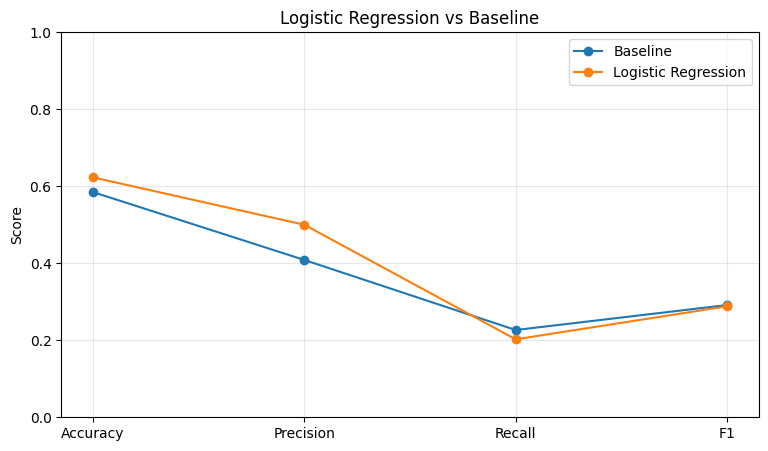

In [69]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1"]

baseline_values = [
    0.5849305222807858,
    0.40859598853868195,
    0.2266369993642721,
    0.2915559190349622
]

model_values = [
    0.6231432678485865,
    0.5,
    0.2024793388429752,
    0.28823529411764703
]

x = range(len(metrics))

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    baseline_values,
    marker="o",
    label="Baseline"
)

plt.plot(
    x,
    model_values,
    marker="o",
    label="Logistic Regression"
)

plt.xticks(list(x), metrics)
plt.ylabel("Score")
plt.title("Logistic Regression vs Baseline")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

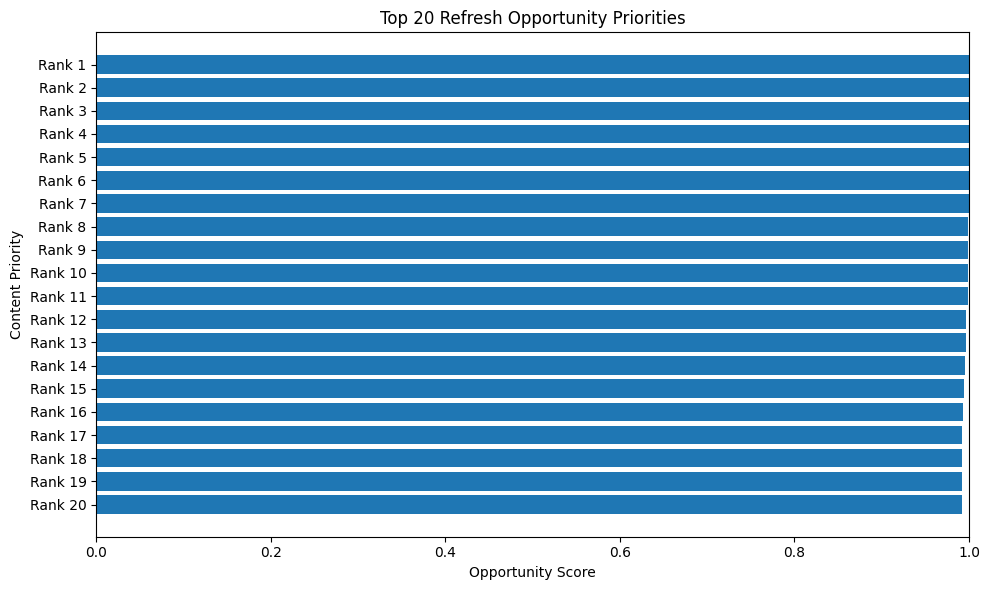

In [70]:
# Top 20 refresh-opportunity scores

top20_plot = ranked_opportunities.head(20).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    range(len(top20_plot)),
    top20_plot["opportunity_score"]
)

plt.yticks(
    range(len(top20_plot)),
    ["Rank " + str(r) for r in top20_plot["rank"]]
)

plt.xlabel("Opportunity Score")
plt.ylabel("Content Priority")
plt.title("Top 20 Refresh Opportunity Priorities")

plt.gca().invert_yaxis()
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [71]:
print(model.named_steps)

{'scaler': StandardScaler(), 'logistic_regression': LogisticRegression(max_iter=1000, random_state=42)}


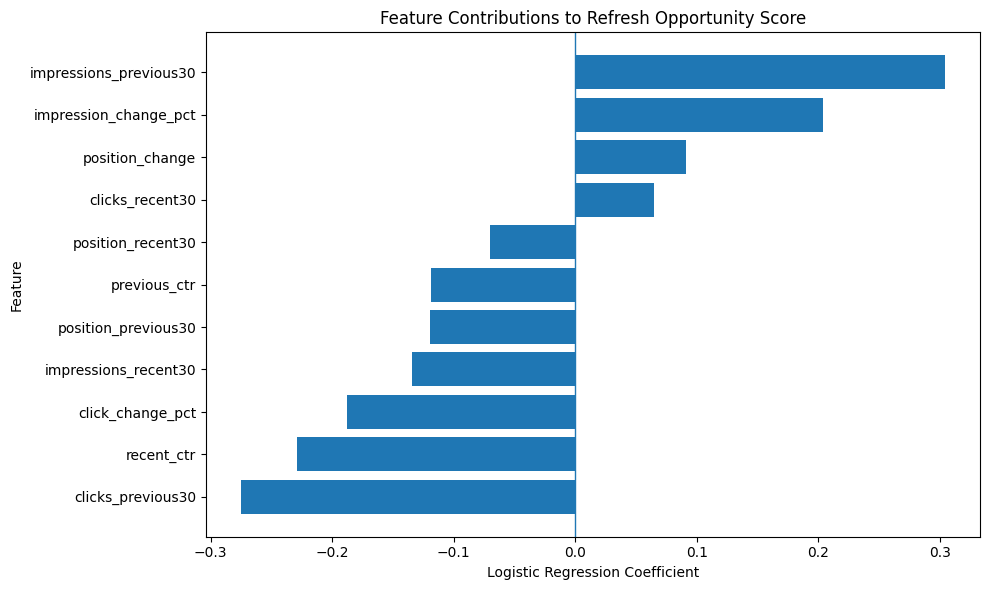

In [72]:
# Get coefficients from the Logistic Regression inside the pipeline

logistic_model = model.named_steps["logistic_regression"]

coef_table = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": logistic_model.coef_[0]
})

coef_table = coef_table.sort_values("coefficient")

plt.figure(figsize=(10, 6))

plt.barh(
    coef_table["feature"],
    coef_table["coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Contributions to Refresh Opportunity Score")

plt.tight_layout()
plt.show()

In [73]:
# Final action playbook for the research paper

paper_recommendations = top20_actions.copy()

paper_recommendations["action"] = "Human review"

paper_recommendations = paper_recommendations[
    [
        "rank",
        "content_hash_id",
        "opportunity_score",
        "impression_change_pct",
        "position_change",
        "reason_code",
        "action"
    ]
]

paper_recommendations.head(20)

,rank,content_hash_id,opportunity_score,impression_change_pct,position_change,reason_code,action
0,1,content_3f5ef78751357313,0.999998,178.705394,-0.518465,High recent visibility,Human review
1,2,content_d5e58406c1d05ec8,0.999996,229.633333,0.586070,Position deteriorated; High recent visibility,Human review
2,3,content_84e12d54a2e96dfe,0.999817,116.407643,0.287492,Position deteriorated; High recent visibility,Human review
3,4,content_4b5e4a6b1f8666b5,0.999787,114.091743,-2.199357,High recent visibility,Human review
4,5,content_41492ed3abf47c6f,0.999770,111.396226,1.264792,Position deteriorated; High recent visibility,Human review
5,6,content_44f34c0a90047651,0.999694,-0.762699,3.409968,Strong visibility decline; Position deteriorat...,Human review
6,7,content_c7ca520a24c97d42,0.999539,102.270000,0.199510,Position deteriorated; High recent visibility,Human review
7,8,content_9d520cf227bade6b,0.999365,128.457944,1.143637,Position deteriorated; High recent visibility,Human review
8,9,content_9605cc5c081a0a9f,0.999245,105.386076,0.647615,Position deteriorated; High recent visibility,Human review
9,10,content_458810b168ad33d9,0.999223,96.506849,1.459071,Position deteriorated; High recent visibility,Human review


## 5-Minute Demo Outline

### 1. Problem — 45 seconds
Explain the research question: which content items show signals that make them worth human review for a possible refresh?

### 2. Data — 45 seconds
Show that the analysis uses the full pseudonymized FlyRank warehouse, including daily content performance and query-level data.

### 3. Method — 1 minute
Explain the time-based design:
- Feature cutoff: 2026-04-30
- Outcome window: 2026-05-01 to 2026-05-30
- Features were calculated only from information available before the cutoff.
- A logistic regression model was compared with a simple baseline.

### 4. Results — 1 minute
The model achieved 0.623 accuracy and 0.598 ROC-AUC on the held-out test set. The baseline achieved 0.585 accuracy and 0.292 F1, while the model achieved 0.288 F1. This means the model improved accuracy but did not improve F1 over the baseline.

### 5. Recommendations — 45 seconds
Show the ranked opportunity table and explain that the ranking is for human review and decision support, not an automatic instruction to refresh pages.

### 6. Limitations — 45 seconds
Emphasize that the analysis is observational, uses pseudonymized data, and does not prove that refreshing content causes better search performance.

## Social-Post Cut

I built a search-intelligence analysis on FlyRank's pseudonymized warehouse to identify content items that may deserve human review for a potential refresh.

The workflow used a time-based feature/outcome split, a simple baseline, and logistic regression. On the held-out test set, the model reached 0.623 accuracy and 0.598 ROC-AUC, compared with 0.585 baseline accuracy.

The most important lesson was not simply building a model, but validating whether it actually beats a baseline and communicating the result honestly. The final output is a ranked opportunity list designed for decision support, not an automated refresh recommendation.

## Employer-Facing Summary

I analyzed FlyRank's pseudonymized search-performance warehouse and built a decision-support workflow to identify content items that may warrant human review for a potential refresh.

I created time-based features, defined a future outcome, compared a logistic regression model against a baseline, and produced a ranked opportunity list while checking for leakage and documenting limitations.

The final model improved accuracy over the baseline (0.623 vs 0.585) but did not improve F1 (0.288 vs 0.292), so the result should be treated as an exploratory ranking system rather than a production-ready predictive model.

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [X] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [X] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
